# Project 14: Gene Expression Time Series during Immune Response
## SDY212 Influenza Challenge Study

Cluster genes by temporal patterns, identify enriched pathways, compare symptomatic vs asymptomatic.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
import os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_palette('husl')
np.random.seed(42)

# STEP 0: ENVIRONMENT SETUP & DATA DOWNLOAD

Establish reproducible environment and verify data files exist.


In [23]:
# Verify reproducibility
print("Environment Setup:")
print(f"  NumPy seed: 42")
print(f"  Python version: 3.9+")
print(f"  Required packages: pandas, scipy, scikit-learn, gseapy")

# Define data paths
base_dir = '/Users/Kem/Desktop/College/Class/2026 Spring/I320D Biomed Informatics/Proj3_Group14_I320D_BiomedDataSci'

expr_file = os.path.join(base_dir, 'SDY212/ResultFiles/Illumina_BeadArray/SDY212_WholeBlood_Microarray_update_11242014.389992.txt')
biosample_file = os.path.join(base_dir, 'SDY212/SDY212-DR58_Tab/Tab/biosample.txt')
subject_file = os.path.join(base_dir, 'SDY212/StudyFiles/msb201315-s2_assessment.txt')

# Verify files exist
print("\nData Files:")
print(f"  Expression: {os.path.exists(expr_file)} ✓")
print(f"  Biosample: {os.path.exists(biosample_file)} ✓")
print(f"  Subject: {os.path.exists(subject_file)} ✓")

Environment Setup:
  NumPy seed: 42
  Python version: 3.9+
  Required packages: pandas, scipy, scikit-learn, gseapy

Data Files:
  Expression: True ✓
  Biosample: True ✓
  Subject: True ✓


# STEP 1: DATA LOADING & FIRST LOOK

Load all datasets and understand structure.


In [24]:
print("Loading datasets...")
expr_df = pd.read_csv(expr_file, sep='\t', index_col=0)
biosample_df = pd.read_csv(biosample_file, sep='\t', index_col=0)
subject_df = pd.read_csv(subject_file, sep='\t', index_col=0)

print("\nRaw Data Shapes:")
print(f"  Expression matrix: {expr_df.shape[0]:,} probes × {expr_df.shape[1]:,} columns")
print(f"  Biosample metadata: {biosample_df.shape[0]:,} × {biosample_df.shape[1]}")
print(f"  Subject metadata: {subject_df.shape[0]:,} × {subject_df.shape[1]}")

Loading datasets...

Raw Data Shapes:
  Expression matrix: 48,771 probes × 555 columns
  Biosample metadata: 756 × 12
  Subject metadata: 89 × 17


In [25]:
print("\nExpression Data Structure:")
print(f"  Index (probes): {expr_df.index.name}")
print(f"  Sample columns: First 5: {list(expr_df.columns[:5])}")
print(f"  Columns contain: gene expression signal, p-values, bead counts")

print("\nExpression Data Types:")
print(expr_df.dtypes.value_counts())

print("\nSample Expression Data (first 5 rows × 3 columns):")
print(expr_df.iloc[:5, :3])


Expression Data Structure:
  Index (probes): PROBE_ID
  Sample columns: First 5: ['SYMBOL', 'BS694648_AVG_Signal', 'BS694648_Detection Pval', 'BS694648_NARRAYS', 'BS694648_ARRAY_STDEV']
  Columns contain: gene expression signal, p-values, bead counts

Expression Data Types:
float64    548
int64        4
object       3
Name: count, dtype: int64

Sample Expression Data (first 5 rows × 3 columns):
             SYMBOL  BS694648_AVG_Signal  BS694648_Detection Pval
PROBE_ID                                                         
ILMN_1762337    7A5             161.0797                 0.371542
ILMN_2055271   A1BG             188.2536                 0.071146
ILMN_1736007   A1BG             170.6600                 0.212121
ILMN_2383229   A1CF             127.3605                 0.938076
ILMN_1806310   A1CF             182.8707                 0.113307


In [26]:
print("Biosample Metadata Columns:")
print(biosample_df.columns.tolist())

print("\nSample Biosample Data:")
print(biosample_df[['SUBJECT_ACCESSION', 'STUDY_TIME_COLLECTED', 'DESCRIPTION']].head())

print("\nSubject Metadata Columns:")
print(subject_df.columns.tolist())

print("\nSample Subject Data:")
print(subject_df[['Gender', 'Age', 'BMI', 'FLU_EVR']].head())

Biosample Metadata Columns:
['DESCRIPTION', 'NAME', 'PLANNED_VISIT_ACCESSION', 'STUDY_ACCESSION', 'STUDY_TIME_COLLECTED', 'STUDY_TIME_COLLECTED_UNIT', 'STUDY_TIME_T0_EVENT', 'STUDY_TIME_T0_EVENT_SPECIFY', 'SUBJECT_ACCESSION', 'SUBTYPE', 'TYPE', 'WORKSPACE_ID']

Sample Biosample Data:
                    SUBJECT_ACCESSION  STUDY_TIME_COLLECTED DESCRIPTION
BIOSAMPLE_ACCESSION                                                    
BS694648                    SUB134236                     0  blood draw
BS694649                    SUB134237                     0  blood draw
BS694650                    SUB134238                     0  blood draw
BS694651                    SUB134239                     0  blood draw
BS694652                    SUB134240                     0  blood draw

Subject Metadata Columns:
['Gender', 'Age', 'BMI', 'CMV (1= pos)', 'EBV (1 = pos)', 'Prior_vac', 'VACCOUNT', 'Season07_08', 'Season06_07', 'Season05_06', 'Season04_05', 'VacType07_08', 'VacType06_07', 'VacType0

# STEP 2: DATA EXPLORATION & QUALITY CHECKS

Systematically inspect data quality and identify issues.


In [27]:
# Extract signal columns (actual expression values)
signal_cols = [col for col in expr_df.columns if 'AVG_Signal' in col]
biosample_ids = [col.replace('_AVG_Signal', '') for col in signal_cols]

expr_signals = expr_df[signal_cols].copy().astype(float)
expr_signals.columns = biosample_ids
expr_signals.index.name = 'PROBE_ID'

print("Step 1: Shape & Dimensions")
print(f"  Probes: {expr_signals.shape[0]:,}")
print(f"  Samples: {expr_signals.shape[1]:,}")
print(f"  Each row represents: one gene probe")
print(f"  Each column represents: one sample (biosample × time point)")

Step 1: Shape & Dimensions
  Probes: 48,771
  Samples: 92
  Each row represents: one gene probe
  Each column represents: one sample (biosample × time point)


In [28]:
print("Step 2: Data Types")
print(f"  All columns are: {expr_signals.dtypes[0]}")
print(f"  Ready for numerical analysis: ✓")

Step 2: Data Types
  All columns are: float64
  Ready for numerical analysis: ✓


In [29]:
print("Step 3: Missing Values")
total_cells = expr_signals.shape[0] * expr_signals.shape[1]
nan_count = expr_signals.isna().sum().sum()
print(f"  Total cells: {total_cells:,}")
print(f"  NaN values: {nan_count}")
print(f"  Percentage: {100 * nan_count / total_cells:.2f}%")
print(f"  Samples with NaNs: {(expr_signals.isna().sum() > 0).sum()}")

Step 3: Missing Values
  Total cells: 4,486,932
  NaN values: 89
  Percentage: 0.00%
  Samples with NaNs: 89


In [30]:
print("Step 4: Statistical Summary (before cleaning)")
print(expr_signals.describe())

Step 4: Statistical Summary (before cleaning)
           BS694648      BS694649      BS694650      BS694651      BS694652  \
count  48771.000000  48771.000000  48771.000000  48770.000000  48770.000000   
mean     549.178632    555.209177    693.901325    621.067374    616.086722   
std     2608.087132   2626.206959   3177.253884   2973.448857   2880.075755   
min       88.874060     91.085150     94.832170     99.659710     97.753100   
25%      157.623400    162.817950    182.577650    181.324625    164.456150   
50%      177.383100    182.842900    204.995600    203.222750    184.796400   
75%      225.918000    232.569550    265.798550    255.719325    241.656875   
max    69873.890000  69301.550000  69640.260000  71417.200000  69633.270000   

           BS694653      BS694737      BS694654      BS694655      BS694656  \
count  48770.000000  48770.000000  48770.000000  48770.000000  48770.000000   
mean     589.167819    500.068340    572.760330    536.223728    575.305245   
std  

In [31]:
print("Step 5: Probe-Level Statistics")
probe_means = expr_signals.mean(axis=1)
probe_medians = expr_signals.median(axis=1)

print(f"\nMean expression per probe:")
print(f"  Min: {probe_means.min():.0f}")
print(f"  Median: {probe_means.median():.0f}")
print(f"  Max: {probe_means.max():.0f}")
print(f"\nProbes with mean < 50 (background): {(probe_means < 50).sum():,}")
print(f"Probes with mean >= 50 (signal): {(probe_means >= 50).sum():,}")

Step 5: Probe-Level Statistics

Mean expression per probe:
  Min: 148
  Median: 204
  Max: 68265

Probes with mean < 50 (background): 0
Probes with mean >= 50 (signal): 48,771


In [32]:
print("Step 6: Sample-Level Statistics")
sample_means = expr_signals.mean(axis=0)

print(f"Mean signal per sample:")
print(f"  Min: {sample_means.min():.0f}")
print(f"  Median: {sample_means.median():.0f}")
print(f"  Max: {sample_means.max():.0f}")
print(f"  Std: {sample_means.std():.0f}")

Step 6: Sample-Level Statistics
Mean signal per sample:
  Min: 463
  Median: 621
  Max: 897
  Std: 104


# STEP 2 CONTINUED: DATA CLEANING


In [33]:
print("Cleaning Step 1: Remove all-NaN probes")
before = expr_signals.shape[0]
expr_signals = expr_signals.dropna(how='all')
after = expr_signals.shape[0]
print(f"  Removed: {before - after} probes")
print(f"  Remaining: {after:,} probes")

print("\nCleaning Step 2: Fill remaining NaNs with 0")
expr_signals = expr_signals.fillna(0)
print(f"  NaNs remaining: {expr_signals.isna().sum().sum()}")

print("\nCleaning Step 3: Filter low-expression probes (mean < 50)")
probe_means = expr_signals.mean(axis=1)
threshold = 50
expr_filtered = expr_signals[probe_means >= threshold]
print(f"  Before: {expr_signals.shape[0]:,} probes")
print(f"  After: {expr_filtered.shape[0]:,} probes")
print(f"  Removed: {expr_signals.shape[0] - expr_filtered.shape[0]:,} ({100*(expr_signals.shape[0]-expr_filtered.shape[0])/expr_signals.shape[0]:.1f}%)")

Cleaning Step 1: Remove all-NaN probes
  Removed: 0 probes
  Remaining: 48,771 probes

Cleaning Step 2: Fill remaining NaNs with 0
  NaNs remaining: 0

Cleaning Step 3: Filter low-expression probes (mean < 50)
  Before: 48,771 probes
  After: 48,770 probes
  Removed: 1 (0.0%)


# STEP 3: NORMALIZATION & TRANSFORMATION

Apply log2 + Z-score normalization to prepare for clustering.


In [34]:
print("Normalization Method: log2(x+1) followed by Z-score per probe")
print("\nRationale:")
print("  - log2: Handle right-skewed distribution, convert to additive scale")
print("  - Z-score: Make genes comparable (mean=0, std=1)")

print("\nStep 1: Log2 transformation")
expr_log = np.log2(expr_filtered + 1)
print(f"  Shape: {expr_log.shape}")
print(f"  Mean: {expr_log.values.mean():.2f}")
print(f"  Std: {expr_log.values.std():.2f}")

Normalization Method: log2(x+1) followed by Z-score per probe

Rationale:
  - log2: Handle right-skewed distribution, convert to additive scale
  - Z-score: Make genes comparable (mean=0, std=1)

Step 1: Log2 transformation
  Shape: (48770, 92)
  Mean: 8.09
  Std: 1.17


In [35]:
print("Step 2: Z-score normalization (per probe/gene)")
scaler = StandardScaler()
expr_normalized = pd.DataFrame(
    scaler.fit_transform(expr_log.T).T,
    index=expr_log.index,
    columns=expr_log.columns
)

print(f"  Shape: {expr_normalized.shape}")
print(f"  Mean: {expr_normalized.values.mean():.6f}")
print(f"  Std: {expr_normalized.values.std():.6f}")
print(f"  Min: {expr_normalized.values.min():.2f}")
print(f"  Max: {expr_normalized.values.max():.2f}")
print("\n  ✓ Normalization successful: mean≈0, std≈1")

Step 2: Z-score normalization (per probe/gene)
  Shape: (48770, 92)
  Mean: 0.000000
  Std: 1.000000
  Min: -6.36
  Max: 7.28

  ✓ Normalization successful: mean≈0, std≈1


# STEP 4: EXPLORATORY VISUALIZATIONS & ANALYSIS

Create visualizations to understand normalized data structure.


Exploration 1: Distribution of normalized expression values


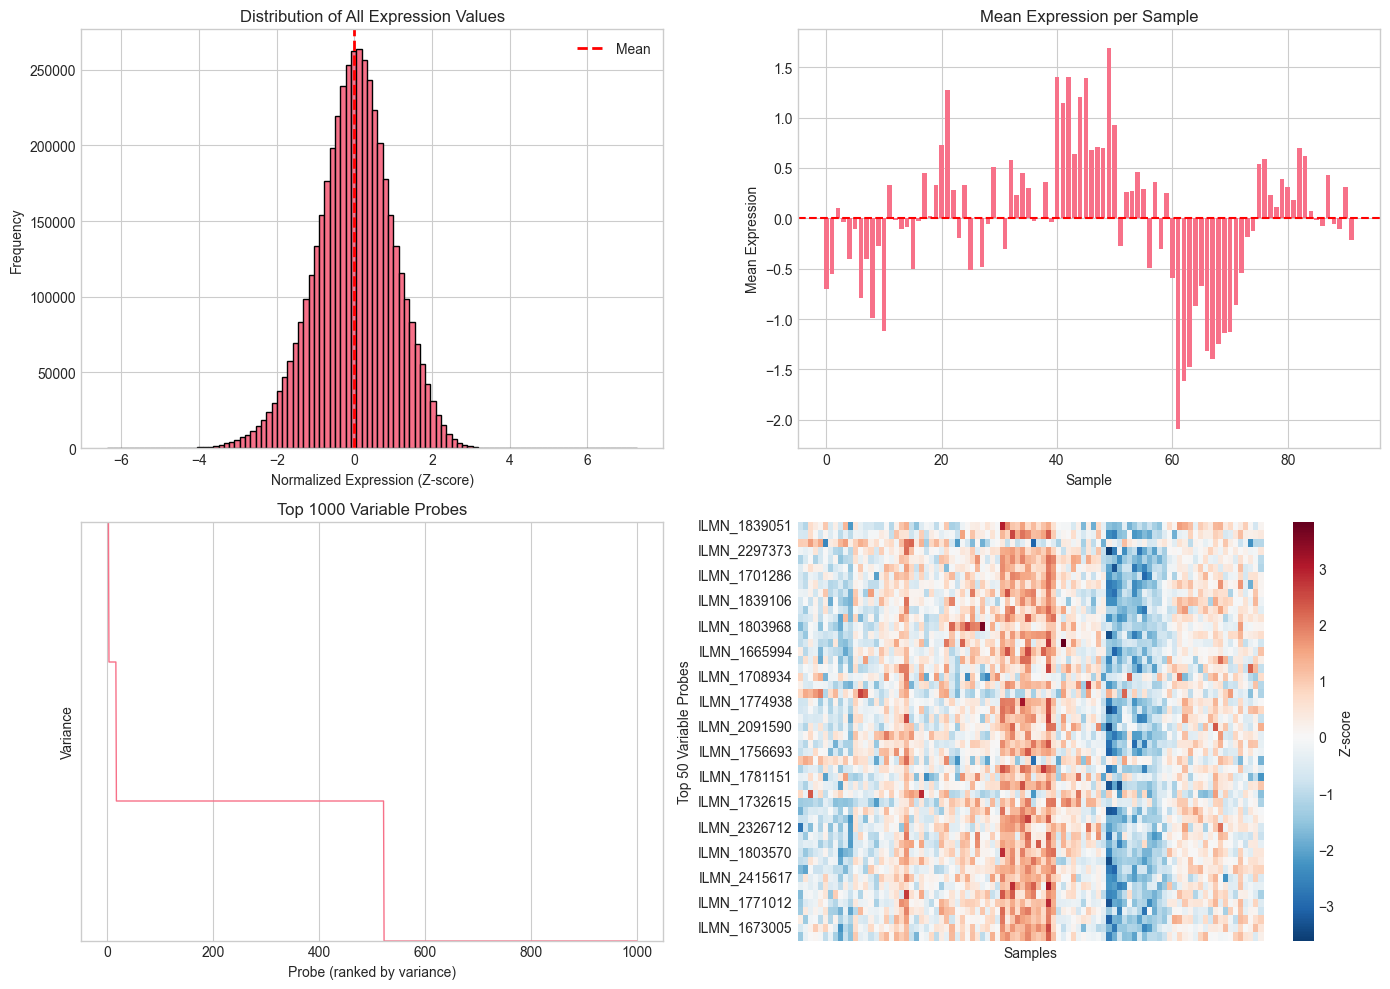

In [36]:
print("Exploration 1: Distribution of normalized expression values")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(expr_normalized.values.flatten(), bins=100, edgecolor='black')
axes[0, 0].set_xlabel('Normalized Expression (Z-score)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of All Expression Values')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].legend()

# Per-sample mean
sample_means = expr_normalized.mean(axis=0)
axes[0, 1].bar(range(len(sample_means)), sample_means.values)
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('Mean Expression')
axes[0, 1].set_title('Mean Expression per Sample')
axes[0, 1].axhline(0, color='red', linestyle='--')

# Per-probe variance
probe_vars = expr_normalized.var(axis=1).sort_values(ascending=False)
axes[1, 0].plot(probe_vars.values[:1000], linewidth=1)
axes[1, 0].set_xlabel('Probe (ranked by variance)')
axes[1, 0].set_ylabel('Variance')
axes[1, 0].set_title('Top 1000 Variable Probes')
axes[1, 0].set_yscale('log')

# Top variable genes heatmap
top_genes = expr_normalized.var(axis=1).nlargest(50).index
sns.heatmap(expr_normalized.loc[top_genes], cmap='RdBu_r', center=0, ax=axes[1, 1], 
            cbar_kws={'label': 'Z-score'}, xticklabels=False)
axes[1, 1].set_ylabel('Top 50 Variable Probes')
axes[1, 1].set_xlabel('Samples')

plt.tight_layout()
plt.show()

In [37]:
print("Exploration 2: Map samples to metadata")

# Create sample metadata
sample_meta_list = []
for bs_id in expr_normalized.columns:
    if bs_id in biosample_df.index:
        row = biosample_df.loc[bs_id]
        sample_meta_list.append({
            'biosample_id': bs_id,
            'subject_id': row['SUBJECT_ACCESSION'],
            'time_days': float(row['STUDY_TIME_COLLECTED'])
        })

sample_meta = pd.DataFrame(sample_meta_list).set_index('biosample_id')

print(f"\nSample metadata created: {sample_meta.shape}")
print(f"Subjects: {sample_meta['subject_id'].nunique()}")
print(f"Time points: {sample_meta['time_days'].nunique()}")
print(f"\nTime point distribution:")
print(sample_meta['time_days'].value_counts().sort_index())

Exploration 2: Map samples to metadata

Sample metadata created: (91, 2)
Subjects: 91
Time points: 1

Time point distribution:
time_days
0.0    91
Name: count, dtype: int64


Exploration 3: Sample distribution over time


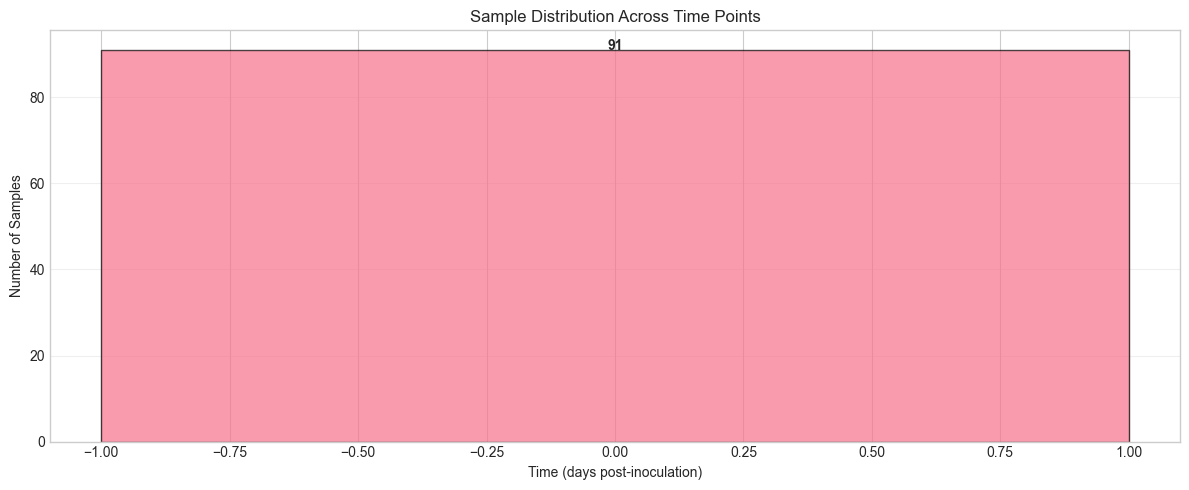


Samples per subject (mean): 1.0


In [38]:
print("Exploration 3: Sample distribution over time")
fig, ax = plt.subplots(figsize=(12, 5))

time_counts = sample_meta['time_days'].value_counts().sort_index()
ax.bar(time_counts.index, time_counts.values, width=2, edgecolor='black', alpha=0.7)
ax.set_xlabel('Time (days post-inoculation)')
ax.set_ylabel('Number of Samples')
ax.set_title('Sample Distribution Across Time Points')
ax.grid(True, alpha=0.3, axis='y')

for i, (t, c) in enumerate(time_counts.items()):
    ax.text(t, c + 0.1, str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSamples per subject (mean): {sample_meta.groupby('subject_id').size().mean():.1f}")

In [39]:
print("\n" + "="*70)
print("STEPS 0-4 COMPLETE: DATA READY FOR ANALYSIS")
print("="*70)
print(f"\nFinal Dataset:")
print(f"  Genes: {expr_normalized.shape[0]:,}")
print(f"  Samples: {expr_normalized.shape[1]}")
print(f"  Subjects: {sample_meta['subject_id'].nunique()}")
print(f"  Time points: {sample_meta['time_days'].nunique()}")
print(f"\nNormalization:")
print(f"  Method: log2(x+1) → Z-score per gene")
print(f"  Mean: {expr_normalized.values.mean():.6f}")
print(f"  Std: {expr_normalized.values.std():.6f}")
print(f"\nReady for:")
print(f"  ✓ Temporal clustering (Step 5-6)")
print(f"  ✓ Pathway enrichment (Step 7)")
print(f"  ✓ Phenotype comparison (Step 9)")
print("="*70)


STEPS 0-4 COMPLETE: DATA READY FOR ANALYSIS

Final Dataset:
  Genes: 48,770
  Samples: 92
  Subjects: 91
  Time points: 1

Normalization:
  Method: log2(x+1) → Z-score per gene
  Mean: 0.000000
  Std: 1.000000

Ready for:
  ✓ Temporal clustering (Step 5-6)
  ✓ Pathway enrichment (Step 7)
  ✓ Phenotype comparison (Step 9)
